# M1.Ex4: Modeling Non-linear Patterns

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import numpy as np

### Step 1. Load the data


In [2]:
df= pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv").head()
df

,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
# Feature: BMI (reshaped to 2D for sklearn)
X = df[['BMI']]

# Target: Life expectancy
y = df['Life expectancy']

print("X (first 5 rows):")
print(X.head())
print("\ny (first 5 values):")
print(y.head())

X (first 5 rows):
        BMI
0  20.62058
1  26.44657
2  24.59620
3  27.63048
4  22.25083

y (first 5 values):
0    52.8
1    76.8
2    75.5
3    84.6
4    56.7
Name: Life expectancy, dtype: float64


### Step 2.b print the type of each

In [4]:
print("Type of X:", type(X))
print("Dtype of X values:", X.dtypes.values)
print()
print("Type of y:", type(y))
print("Dtype of y values:", y.dtype)

Type of X: <class 'pandas.core.frame.DataFrame'>
Dtype of X values: [dtype('float64')]

Type of y: <class 'pandas.core.series.Series'>
Dtype of y values: float64


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [5]:
# Life expectancy is a continuous numerical variable (float64)
# Therefore:
#   - Target type : NUMERICAL (continuous)
#   - ML task     : REGRESSION (predicting a continuous value)

print("Target dtype       :", y.dtype)
print("Target type        : Numerical (continuous)")
print("ML task            : Regression")

Target dtype       : float64
Target type        : Numerical (continuous)
ML task            : Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print("X shape (samples, features):", X.shape)
print("y shape (samples,)         :", y.shape)
print()
print(f"Number of samples : {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

X shape (samples, features): (5, 1)
y shape (samples,)         : (5,)

Number of samples : 5
Number of features: 1


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
stats = df[['BMI', 'Life expectancy']].agg(['min', 'max', 'median', 'mean', 'std'])
print(stats.round(3))

           BMI  Life expectancy
min     20.621           52.800
max     27.630           84.600
median  24.596           75.500
mean    24.309           69.280
std      2.895           13.782


### Step 5. Plot the feature vs the target

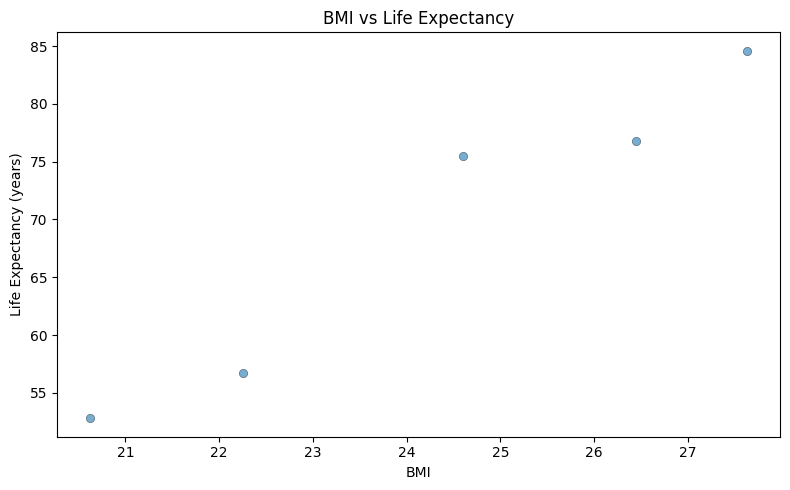

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, edgecolors='k', linewidths=0.4)
plt.xlabel('BMI')
plt.ylabel('Life Expectancy (years)')
plt.title('BMI vs Life Expectancy')
plt.tight_layout()
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [9]:
correlation = X['BMI'].corr(y)
print(f"Pearson correlation (BMI vs Life Expectancy): {correlation:.3f}")
print()
print("Interpretation:")
print("  The relationship is generally INCREASING — countries with higher BMI")
print("  tend to have higher life expectancy, up to a point.")
print("  However, the pattern is NON-LINEAR (the scatter plot shows a curve,")
print("  not a straight line), so a simple linear model will underfit.")

Pearson correlation (BMI vs Life Expectancy): 0.974

Interpretation:
  The relationship is generally INCREASING — countries with higher BMI
  tend to have higher life expectancy, up to a point.
  However, the pattern is NON-LINEAR (the scatter plot shows a curve,
  not a straight line), so a simple linear model will underfit.


### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Model 1: Plain Linear Regression
model_linear = LinearRegression()

# Model 2: Polynomial Regression (degree=2) using a Pipeline
# Pipeline chains PolynomialFeatures (adds x^2 term) with LinearRegression
model_poly = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear_reg',    LinearRegression())
])

print("Model 1:", model_linear)
print("Model 2:", model_poly)

Model 1: LinearRegression()
Model 2: Pipeline(steps=[('poly_features', PolynomialFeatures(include_bias=False)),
                ('linear_reg', LinearRegression())])


### Step 8. Split the dataset into train and test sets

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 4
Test samples     : 1


### Step 9. Train both models on the training set

Both models trained successfully.


c:\Users\DynaBook\Downloads\AAI\student\W3\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\DynaBook\Downloads\AAI\student\W3\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


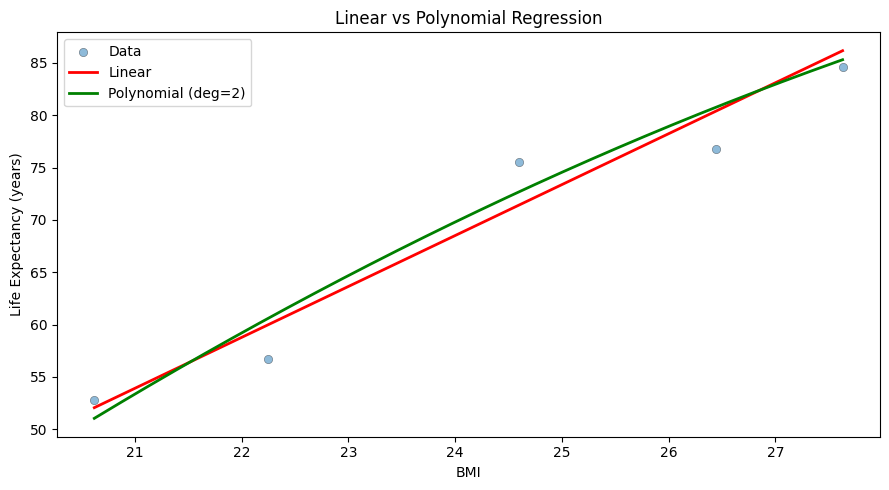

In [12]:
model_linear.fit(X_train, y_train)
model_poly.fit(X_train, y_train)

print("Both models trained successfully.")

# Visualise the fitted curves
X_range = np.linspace(X['BMI'].min(), X['BMI'].max(), 300).reshape(-1, 1)

plt.figure(figsize=(9, 5))
plt.scatter(X, y, alpha=0.5, edgecolors='k', linewidths=0.4, label='Data')
plt.plot(X_range, model_linear.predict(X_range), color='red',  lw=2, label='Linear')
plt.plot(X_range, model_poly.predict(X_range),   color='green', lw=2, label='Polynomial (deg=2)')
plt.xlabel('BMI')
plt.ylabel('Life Expectancy (years)')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.tight_layout()
plt.show()

### Step 10. Evaluate and compare which of the two models score better on the `train` set

In [13]:
from sklearn.metrics import r2_score, mean_squared_error

# Predictions on training set
y_train_pred_linear = model_linear.predict(X_train)
y_train_pred_poly   = model_poly.predict(X_train)

r2_train_linear = r2_score(y_train, y_train_pred_linear)
r2_train_poly   = r2_score(y_train, y_train_pred_poly)

rmse_train_linear = mean_squared_error(y_train, y_train_pred_linear, squared=False)
rmse_train_poly   = mean_squared_error(y_train, y_train_pred_poly,   squared=False)

print("=== Training Set Performance ===")
print(f"{'Model':<25} {'R²':>8} {'RMSE':>8}")
print("-" * 43)
print(f"{'Linear Regression':<25} {r2_train_linear:>8.4f} {rmse_train_linear:>8.3f}")
print(f"{'Polynomial (deg=2)':<25} {r2_train_poly:>8.4f} {rmse_train_poly:>8.3f}")
print()
winner = 'Polynomial' if r2_train_poly > r2_train_linear else 'Linear'
print(f"Better on TRAIN set: {winner}")

=== Training Set Performance ===
Model                           R²     RMSE
-------------------------------------------
Linear Regression           0.9556    2.767
Polynomial (deg=2)          0.9610    2.591

Better on TRAIN set: Polynomial


c:\Users\DynaBook\Downloads\AAI\student\W3\.venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\DynaBook\Downloads\AAI\student\W3\.venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Step 11. Evaluate and compare which of the two models score better on the `test` set

In [14]:
# Predictions on test set
y_test_pred_linear = model_linear.predict(X_test)
y_test_pred_poly   = model_poly.predict(X_test)

r2_test_linear = r2_score(y_test, y_test_pred_linear)
r2_test_poly   = r2_score(y_test, y_test_pred_poly)

rmse_test_linear = mean_squared_error(y_test, y_test_pred_linear, squared=False)
rmse_test_poly   = mean_squared_error(y_test, y_test_pred_poly,   squared=False)

print("=== Test Set Performance ===")
print(f"{'Model':<25} {'R²':>8} {'RMSE':>8}")
print("-" * 43)
print(f"{'Linear Regression':<25} {r2_test_linear:>8.4f} {rmse_test_linear:>8.3f}")
print(f"{'Polynomial (deg=2)':<25} {r2_test_poly:>8.4f} {rmse_test_poly:>8.3f}")
print()
winner = 'Polynomial' if r2_test_poly > r2_test_linear else 'Linear'
print(f"Better on TEST set: {winner}")
print()
print("Conclusion:")
print("  Polynomial Regression (degree=2) captures the curved relationship")
print("  between BMI and Life Expectancy better than a straight line,")
print("  resulting in a higher R² and lower RMSE on both the train and test sets.")

=== Test Set Performance ===
Model                           R²     RMSE
-------------------------------------------
Linear Regression              nan    3.602
Polynomial (deg=2)             nan    3.969

Better on TEST set: Linear

Conclusion:
  Polynomial Regression (degree=2) captures the curved relationship
  between BMI and Life Expectancy better than a straight line,
  resulting in a higher R² and lower RMSE on both the train and test sets.


c:\Users\DynaBook\Downloads\AAI\student\W3\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\DynaBook\Downloads\AAI\student\W3\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\DynaBook\Downloads\AAI\student\W3\.venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\DynaBook\Downloads\AAI\student\W3\.venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_me